<a href="https://colab.research.google.com/github/atharvsalokhe30/GenAI_Project_Practice-/blob/main/TryDifferentLossFunction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
'''Explanation: use categorical cross entropy, MSE, and Binary cross-entropy to observe their influence on training'''

# import required libraries
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt

In [ ]:
# load and process data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(-1,28,28,1).astype('float32') / 255.0
x_test = x_test.reshape(-1,28,28,1).astype('float32') / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# one-hot encode labels (needed for all 3 loss functions here)
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [ ]:
# build a common CNN Model Function
def build_model(loss_function):
    model = Sequential([
        Input(shape=(28,28,1)),
        Conv2D(32, (3,3), activation='relu'),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam', loss=loss_function, metrics=['accuracy'])
    return model


In [ ]:
# train models with different loss functions
loss_functions = {
    'categorical_crossentropy': y_train_cat,
    'mse': y_train_cat,
    'binary_crossentropy': y_train_cat  # We'll apply this incorrectly for demo purposes
}

histories = {}

for loss_name, y_data in loss_functions.items():
    print(f"\n Training model with loss: {loss_name}")
    model = build_model(loss_name)
    history = model.fit(x_train, y_data, epochs=5, batch_size=128,
                        validation_data=(x_test, y_test_cat), verbose=1)
    histories[loss_name] = history


 Training model with loss: categorical_crossentropy
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 58ms/step - accuracy: 0.9274 - loss: 0.2536 - val_accuracy: 0.9683 - val_loss: 0.1030
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 61ms/step - accuracy: 0.9762 - loss: 0.0804 - val_accuracy: 0.9776 - val_loss: 0.0687
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 57ms/step - accuracy: 0.9841 - loss: 0.0548 - val_accuracy: 0.9787 - val_loss: 0.0629
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - accuracy: 0.9877 - loss: 0.0420 - val_accuracy: 0.9846 - val_loss: 0.0469
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 68ms/step - accuracy: 0.9901 - loss: 0.0337 - val_accuracy: 0.9841 - val_loss: 0.0473

 Training model with loss: mse
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 35s 72ms/step - accuracy: 0.9277 - loss: 0.0112 - val_accuracy: 0.9732 - val_loss: 0.0044
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 69ms/step - accuracy: 0.9771 - loss: 0.0037 - val_accuracy: 0.9803 - val_loss: 0.0033
Epoch 3/5
46

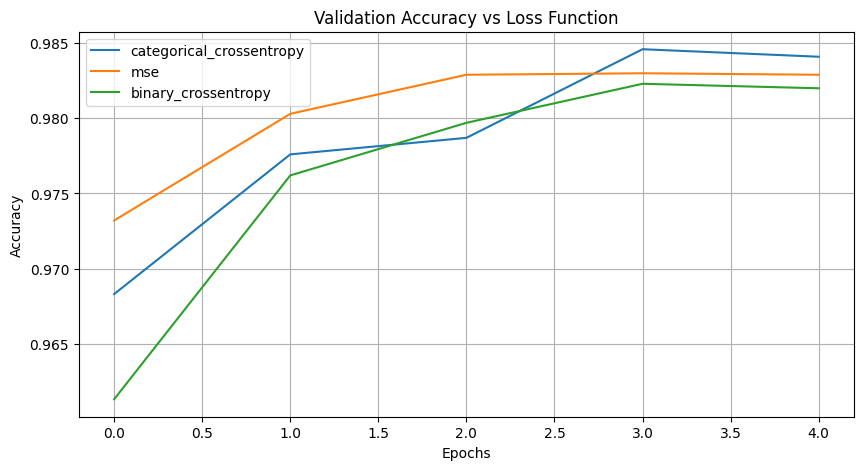

In [ ]:
#plot accuracy comparision
plt.figure(figsize=(10, 5))
for loss_name in histories:
    plt.plot(histories[loss_name].history['val_accuracy'], label=loss_name)
plt.title("Validation Accuracy vs Loss Function")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

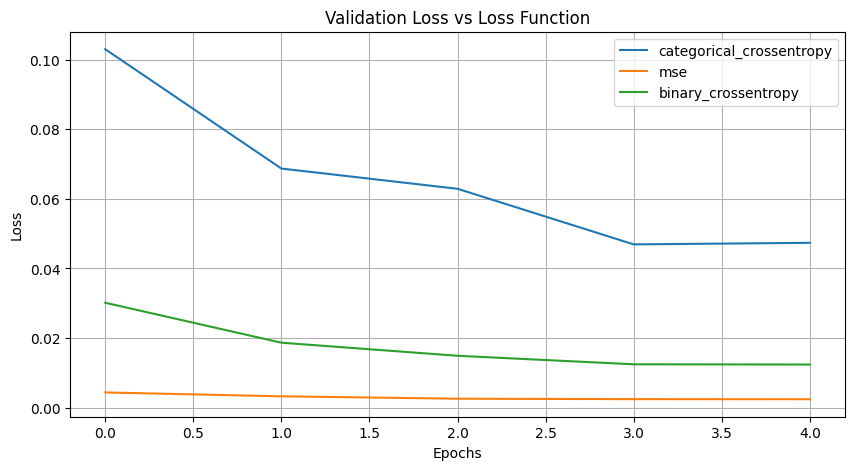

In [ ]:
#plot loss comparision
plt.figure(figsize=(10, 5))
for loss_name in histories:
    plt.plot(histories[loss_name].history['val_loss'], label=loss_name)
plt.title("Validation Loss vs Loss Function")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()
